In [5]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd


# ============================================================
# 2. CARGAR LOS DATOS
# ============================================================

timesheet = pd.read_csv("../data/timesheet.csv")

# Ver las primeras filas
print(timesheet.head())


# ============================================================
# 3. CALCULAR EL PROMEDIO DE HOURS-LOGGED Y MILES-LOGGED
#    AGRUPADO POR CONDUCTOR
# ============================================================

means_by_driver = (
    timesheet
    .groupby("driverId")[["hours-logged", "miles-logged"]]
    .mean()
    .reset_index()
)

print("\nPromedios por conductor:")
print(means_by_driver)


# ============================================================
# 4. CREAR LA TABLA TIMESHEET_WITH_MEANS
#    AGREGANDO EL PROMEDIO DE HOURS-LOGGED DE CADA CONDUCTOR
# ============================================================

timesheet_with_means = timesheet.copy()

timesheet_with_means["mean-hours-logged"] = (
    timesheet_with_means
    .groupby("driverId")["hours-logged"]
    .transform("mean")
)


# ============================================================
# 5. MOSTRAR RESULTADO
# ============================================================

print("\nTabla timesheet_with_means:")
print(timesheet_with_means.head(20))

   driverId  week  hours-logged  miles-logged
0        10     1            70          3300
1        10     2            70          3300
2        10     3            60          2800
3        10     4            70          3100
4        10     5            70          3200

Promedios por conductor:
    driverId  hours-logged  miles-logged
0         10     62.153846   2829.807692
1         11     70.038462   3448.076923
2         12     50.750000   2614.653846
3         13     52.442308   2579.346154
4         14     53.480769   2627.384615
5         15     52.576923   2668.269231
6         16     52.807692   2638.557692
7         17     51.942308   2615.230769
8         18     51.038462   2650.653846
9         19     52.653846   2653.230769
10        20     50.846154   2587.769231
11        21     52.903846   2667.673077
12        22     52.557692   2645.192308
13        23     52.884615   2653.461538
14        24     50.903846   2585.788462
15        25     52.365385   2676.538462
1

In [6]:
# ============================================================
# 6. CREAR TIMESHEET_BELOW
#    Filtrar horas menores al promedio de cada conductor
# ============================================================

timesheet_below = timesheet_with_means[
    timesheet_with_means["hours-logged"]
    < timesheet_with_means["mean-hours-logged"]
].copy()

print("\nTabla timesheet_below:")
print(timesheet_below.head(20))


# ============================================================
# 7. CREAR SUM_TIMESHEET
#    Sumar horas y millas por conductor
# ============================================================

sum_timesheet = (
    timesheet
    .groupby("driverId")[["hours-logged", "miles-logged"]]
    .sum()
    .reset_index()
)

print("\nTabla sum_timesheet:")
print(sum_timesheet.head(20))


# ============================================================
# 8. CREAR MIN_MAX_TIMESHEET
#    Calcular mínimo y máximo de horas por conductor
# ============================================================

min_max_timesheet = (
    timesheet
    .groupby("driverId")["hours-logged"]
    .agg(["min", "max"])
    .reset_index()
)

print("\nTabla min_max_timesheet:")
print(min_max_timesheet.head(20))


Tabla timesheet_below:
    driverId  week  hours-logged  miles-logged  mean-hours-logged
2         10     3            60          2800          62.153846
9         10    10            50          2500          62.153846
19        10    20            30          1200          62.153846
20        10    21            50          2500          62.153846
25        10    26            60          2600          62.153846
27        10    28            33          1200          62.153846
34        10    35             0             0          62.153846
35        10    36            19          1000          62.153846
45        10    46            57          2300          62.153846
50        10    51             5           150          62.153846
51        10    52             0             0          62.153846
52        11     1            50          3000          70.038462
57        11     6            70          3400          70.038462
66        11    15             0             0      

In [8]:
# ============================================================
# 9. CARGAR LA TABLA DRIVERS
# ============================================================

drivers = pd.read_csv("../data/drivers.csv")


# ============================================================
# 10. CREAR SUMMARY
#     Combinar sum_timesheet con driverId y name de drivers
# ============================================================

summary = pd.merge(
    sum_timesheet,
    drivers[["driverId", "name"]],
    on="driverId"
)

print("\nTabla summary:")
print(summary.head(20))


Tabla summary:
    driverId  hours-logged  miles-logged                 name
0         10          3232        147150    George Vetticaden
1         11          3642        179300       Jamie Engesser
2         12          2639        135962          Paul Coddin
3         13          2727        134126          Joe Niemiec
4         14          2781        136624           Adis Cesir
5         15          2734        138750         Rohit Bakshi
6         16          2746        137205           Tom McCuch
7         17          2701        135992          Eric Mizell
8         18          2654        137834            Grant Liu
9         19          2738        137968           Ajay Singh
10        20          2644        134564         Chris Harris
11        21          2751        138719         Jeff Markham
12        22          2733        137550        Nadeem Asghar
13        23          2750        137980            Adam Diaz
14        24          2647        134461          Don 

In [9]:
# ============================================================
# 11. GUARDAR SUMMARY EN LA CARPETA SUBMISSION
# ============================================================

summary.to_csv(
    "../submission/summary.csv",
    index=False
)

print("Archivo guardado correctamente en ../submission/summary.csv")

Archivo guardado correctamente en ../submission/summary.csv



Top 10 conductores por millas:
    driverId  hours-logged  miles-logged                 name
1         11          3642        179300       Jamie Engesser
0         10          3232        147150    George Vetticaden
23        33          2759        139285    Sridhara Sabbella
15        25          2723        139180  Jean-Philippe Playe
29        39          2745        138788         David Kaiser
5         15          2734        138750         Rohit Bakshi
25        35          2728        138727          Emil Siemes
11        21          2751        138719         Jeff Markham
31        41          2723        138407        Greg Phillips
19        29          2760        138255           Teddy Choi


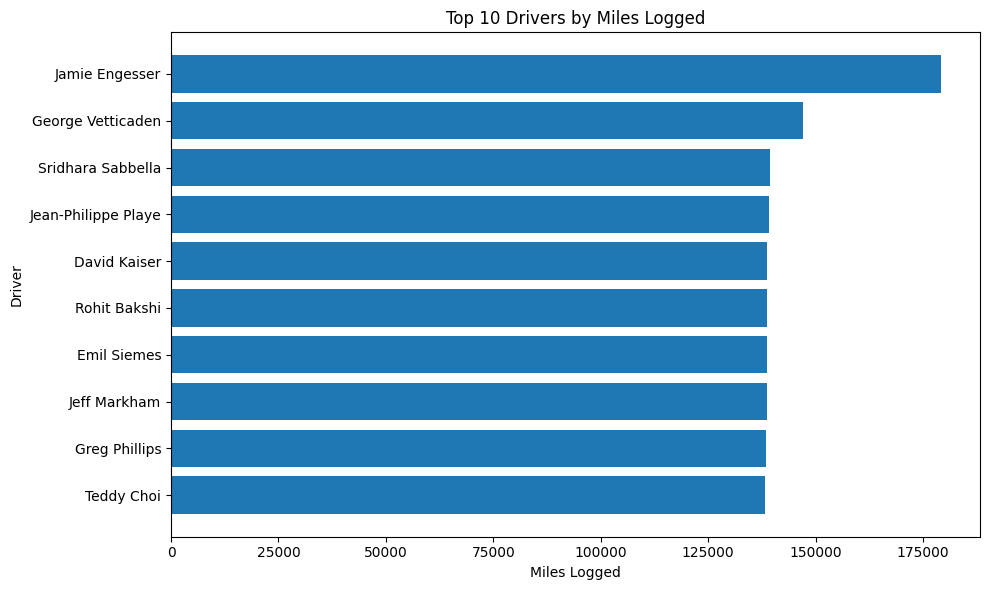

In [12]:
# ============================================================
# 12. CREAR TOP10
#     Seleccionar los 10 conductores con más millas
# ============================================================

top10 = (
    summary
    .sort_values("miles-logged", ascending=False)
    .head(10)
)

print("\nTop 10 conductores por millas:")
print(top10)


# ============================================================
# 13. CREAR GRÁFICO DE BARRAS HORIZONTALES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top10["name"],
    top10["miles-logged"]
)

# Invertir el eje Y para que el conductor con más millas
# aparezca en la parte superior
plt.gca().invert_yaxis()

plt.xlabel("Miles Logged")
plt.ylabel("Driver")
plt.title("Top 10 Drivers by Miles Logged")

plt.tight_layout()


# ============================================================
# 14. GUARDAR GRÁFICO EN SUBMISSION
# ============================================================

plt.savefig(
    "../submission/top10_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()